In [24]:
import collections
import math
import torch
from torch import nn
import d2l.torch as d2l


class Seq2SeqEncoder(d2l.Encoder):
    def __init__(self, vocab_size, emb_size, hidden_size, num_layers, dropout=0.0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_size)
        self.rnn = nn.GRU(emb_size, hidden_size, num_layers, dropout=dropout)

    def forward(self, X, *args):
        X = self.embedding(X)
        X = X.permute(1, 0, 2)
        return self.rnn(X)


encoder = Seq2SeqEncoder(10, 8, 16, 2)
X = torch.zeros((4, 7), dtype=torch.long)
out, state = encoder(X)


class Seq2SeqDecoder(d2l.Decoder):
    def __init__(self, vocab_size, emb_size, hidden_size, num_layers, dropout=0.0):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_size)
        self.rnn = nn.GRU(
            emb_size + hidden_size, hidden_size, num_layers, dropout=dropout
        )
        self.dense = nn.Linear(hidden_size, vocab_size)

    def init_state(self, enc_outputs, *args):
        return enc_outputs[1]

    def forward(self, X, state):
        # 由Batch_first转为时间步数开头
        X = self.emb(X).permute(1, 0, 2)
        context = state[-1].repeat(X.shape[0], 1, 1)
        X_and_context = torch.cat((X, context), dim=2)
        out, state = self.rnn(X_and_context, state)

        return self.dense(out).permute(1, 0, 2), state


def sequence_mask(X: torch.Tensor, valid_len, value=0):
    maxlen = X.size(1)
    mask = (
        torch.arange((maxlen), dtype=torch.float32, device=X.device)[None, :]
        < valid_len[:, None]
    )  # [:,None]取出所有元素作为行，再加一个维度1，做广播运算，每一行只有valid_len的位置为True
    X[~mask] = value
    return X

In [14]:
class MaskedSoftmaxCELoss(nn.CrossEntropyLoss):
    def forward(self, pred, label, valid_len):
        weights = torch.ones_like(label)
        weights = sequence_mask(weights, valid_len)
        self.reduction = (
            "none"  # 后面调用super().forward时，内部需要访问self.reduction,所以提前设好
        )
        unweighted_loss = super().forward(pred.permute(0, 2, 1), label)
        weighted_loss = (unweighted_loss * weights).mean(
            dim=1
        )  # 最终返回(batch_size,),也就是一个句子（样本）一个loss
        return weighted_loss


loss = MaskedSoftmaxCELoss()
loss(
    torch.ones(3, 4, 10), torch.ones((3, 4), dtype=torch.long), torch.tensor([4, 2, 0])
)

tensor([2.3026, 1.1513, 0.0000])

In [15]:
def train_seq2seq(net, data_iter, lr, num_epochs, tgt_vocab, device):
    # 给网络中的Linear 和 GRU权重统一做Xavier初始化，这个初始化方法可以让训练更稳定，它设定的权重初始值可以做到尽量不会因为训练层数增多而越来越大或越来越小
    def xavier_init_weights(m):
        if type(m) == nn.Linear:
            nn.init.xavier_uniform_(m.weight)
        if type(m) == nn.GRU:
            for param in m._flat_weights_names:
                if "weight" in param:
                    nn.init.xavier_uniform_(m._parameters[param])  # type: ignore

    net.apply(xavier_init_weights)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss = MaskedSoftmaxCELoss()
    net.train()
    animator = d2l.Animator(xlabel="epoch", ylabel="loss", xlim=[10, num_epochs])
    for epoch in range(num_epochs):
        timer = d2l.Timer()
        metric = d2l.Accumulator(2)
        for batch in data_iter:
            optimizer.zero_grad()
            X, X_valid_len, Y, Y_valid_len = [x.to(device) for x in batch]
            # 表示开始的整数ID，列表乘以一个数是列表重复，如[5]*2=[5,5]
            bos = torch.tensor(
                [tgt_vocab["<bos>"]] * Y.shape[0], device=device
            ).reshape(-1, 1)
            dec_input = torch.cat(
                [bos, Y[:, :-1]], 1
            )  # 这里相当于做一个偏移，之后要用它来训练模型由上一个输入推出下一个输入
            # 训练时是整个偏移序列输入，预测每一个单词的下一个，得到最终完整预测序列，然后算loss,是teacher forcing方法
            Y_hat = net(X, dec_input, X_valid_len)
            l = loss(Y_hat, Y, Y_valid_len)
            l.sum().backward()
            d2l.grad_clipping(net, 1)  # 防止梯度爆炸，把整体范数限制为1
            num_tokens = Y_valid_len.sum()
            optimizer.step()
            with torch.no_grad():
                metric.add(l.sum(), num_tokens)
        if (epoch + 1) % 10 == 0:
            animator.add(epoch + 1, (metric[0] / metric[1]))

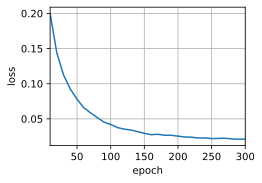

In [16]:
embed_size, num_hiddens, num_layers, dropout = 32, 32, 2, 0.1
batch_size, num_steps = 64, 10
lr, num_epochs, device = 0.005, 300, d2l.try_gpu()

train_iter, src_vocab, tgt_vocab = d2l.load_data_nmt(batch_size, num_steps)

encoder = Seq2SeqEncoder(len(src_vocab), embed_size, num_hiddens, num_layers, dropout)

decoder = Seq2SeqDecoder(len(tgt_vocab), embed_size, num_hiddens, num_layers, dropout)

net = d2l.EncoderDecoder(encoder, decoder)

train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)

In [17]:
def predict_seq2seq(
    net,
    src_sentence,
    src_vocab,
    tgt_vocab,
    num_steps,
    device,
    save_attention_weights=False,
):
    """序列到序列模型的预测"""

    # 进入预测模式，关闭 dropout 等
    net.eval()

    # 把输入英文句子切词，然后转成 token id，并在末尾加 <eos>
    src_tokens = src_vocab[src_sentence.lower().split(" ")] + [src_vocab["<eos>"]]

    # 输入序列真正的有效长度
    enc_valid_len = torch.tensor([len(src_tokens)], device=device)

    # 截断或者 padding 到固定长度 num_steps
    src_tokens = d2l.truncate_pad(src_tokens, num_steps, src_vocab["<pad>"])

    # (num_steps,) -> (1, num_steps)
    # 这里的 1 相当于 batch_size=1
    enc_X = torch.unsqueeze(
        torch.tensor(src_tokens, dtype=torch.long, device=device), dim=0
    )

    # Encoder 前向传播
    enc_outputs = net.encoder(enc_X, enc_valid_len)

    # 根据 Encoder 输出初始化 Decoder 状态
    dec_state = net.decoder.init_state(enc_outputs, enc_valid_len)

    # Decoder 的第一个输入是 <bos>
    # shape: (1, 1)
    dec_X = torch.unsqueeze(
        torch.tensor([tgt_vocab["<bos>"]], dtype=torch.long, device=device), dim=0
    )

    output_seq, attention_weight_seq = [], []

    # 自回归预测
    for _ in range(num_steps):
        Y, dec_state = net.decoder(dec_X, dec_state)

        # Y shape 大致：
        # (1, 1, vocab_size)
        # 在 vocab_size 维找概率最大的 token
        dec_X = Y.argmax(dim=2)

        # 取出这个 token id，变成普通 Python 整数
        pred = dec_X.squeeze(dim=0).type(torch.int32).item()

        # 如果需要，保存 attention 权重
        if save_attention_weights:
            attention_weight_seq.append(net.decoder.attention_weights)

        # 预测到 <eos>，说明句子结束
        if pred == tgt_vocab["<eos>"]:
            break

        # 保存预测 token
        output_seq.append(pred)

    # token id -> 法语单词，并用空格拼起来
    return (" ".join(tgt_vocab.to_tokens(output_seq)), attention_weight_seq)

In [18]:
import math
import collections


def bleu(pred_seq, label_seq, k):
    """计算BLEU"""

    pred_tokens = pred_seq.split(" ")
    label_tokens = label_seq.split(" ")

    len_pred = len(pred_tokens)
    len_label = len(label_tokens)

    # 惩罚预测序列过短
    score = math.exp(min(0, 1 - len_label / len_pred))

    # 分别计算 1-gram, 2-gram, ..., k-gram
    for n in range(1, k + 1):
        num_matches = 0
        label_subs = collections.defaultdict(int)

        # 统计真实序列中每种 n-gram 出现的次数
        for i in range(len_label - n + 1):
            label_subs[" ".join(label_tokens[i : i + n])] += 1

        # 统计预测序列中有多少 n-gram 能和真实序列匹配
        for i in range(len_pred - n + 1):
            ngram = " ".join(pred_tokens[i : i + n])

            if label_subs[ngram] > 0:
                num_matches += 1
                label_subs[ngram] -= 1

        # 把当前 n-gram 的匹配率乘进最终 BLEU
        score *= math.pow(num_matches / (len_pred - n + 1), math.pow(0.5, n))

    return score

In [ ]:
engs = ["go .", "i lost .", "he's calm .", "i'm home ."]

fras = ["va !", "j'ai perdu .", "il est calme .", "je suis chez moi ."]

for eng, fra in zip(engs, fras):
    translation, attention_weight_seq = predict_seq2seq(
        net, eng, src_vocab, tgt_vocab, num_steps, device
    )

    print(f"{eng} => {translation}, " f"bleu {bleu(translation, fra, k=2):.3f}")

go . => va !, bleu 1.000
i lost . => j'ai perdu bien ., bleu 0.658
he's calm . => il court aller ? feu suis feu, bleu 0.000
i'm home . => je suis faible suis ., bleu 0.548


In [20]:
# attention seq2seq
import torch
from torch import nn
import d2l.torch as d2l


class AttentionDecoder(d2l.Decoder):
    def __init__(self):
        super().__init__()

    # 定义一个属性，而且规定子类必须重写，不然调用这个基类的属性会raise error
    @property
    def attention_weights(self):
        raise NotImplementedError

In [ ]:
class Seq2SeqAttentionDecoder(AttentionDecoder):
    def __init__(
        self, vocab_size, embed_size, num_hiddens, num_layers, dropout=0.0, **kwargs
    ):
        super(Seq2SeqAttentionDecoder, self).__init__(**kwargs)

        self.attention = d2l.AdditiveAttention(num_hiddens, dropout)

        self.embedding = nn.Embedding(vocab_size, embed_size)

        self.rnn = nn.GRU(
            embed_size + num_hiddens, num_hiddens, num_layers, dropout=dropout
        )

        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        outputs, hidden_state = enc_outputs

        return (outputs.permute(1, 0, 2), hidden_state, enc_valid_lens)

    def forward(self, X, state):
        # 解包 decoder state
        enc_outputs, hidden_state, enc_valid_lens = state

        # (batch_size, num_steps)
        #      ↓ embedding
        # (batch_size, num_steps, embed_size)
        #      ↓ permute
        # (num_steps, batch_size, embed_size)
        X = self.embedding(X).permute(1, 0, 2)

        outputs, self._attention_weights = [], []

        # 每次处理一个时间步
        for x in X:
            # hidden_state[-1]:
            # (batch_size, num_hiddens)
            #
            # → (batch_size, 1, num_hiddens)
            #
            # 作为当前 attention 的 query
            query = torch.unsqueeze(hidden_state[-1], dim=1)

            # Encoder所有时间步输出既作为keys又作为values
            context = self.attention(query, enc_outputs, enc_outputs, enc_valid_lens)

            # x:
            # (batch_size, embed_size)
            #
            # x.unsqueeze(1):
            # (batch_size, 1, embed_size)
            #
            # context:
            # (batch_size, 1, num_hiddens)
            #
            # 拼起来
            x = torch.cat((context, torch.unsqueeze(x, dim=1)), dim=-1)

            # GRU要求：
            # (num_steps, batch_size, input_size)
            #
            # 当前只有一个时间步，所以变成：
            # (1, batch_size, embed_size + num_hiddens)
            out, hidden_state = self.rnn(x.permute(1, 0, 2), hidden_state)

            outputs.append(out)

            self._attention_weights.append(self.attention.attention_weights)

        # 把所有时间步重新拼起来
        outputs = self.dense(torch.cat(outputs, dim=0))

        # (num_steps, batch_size, vocab_size)
        # →
        # (batch_size, num_steps, vocab_size)
        return (outputs.permute(1, 0, 2), [enc_outputs, hidden_state, enc_valid_lens])

    @property
    def attention_weights(self):
        return self._attention_weights

In [22]:
encoder = d2l.Seq2SeqEncoder(vocab_size=10, embed_size=8, num_hiddens=16, num_layers=2)
encoder.eval()

decoder = Seq2SeqAttentionDecoder(
    vocab_size=10, embed_size=8, num_hiddens=16, num_layers=2
)
decoder.eval()

X = torch.zeros((4, 7), dtype=torch.long)

state = decoder.init_state(encoder(X), None)

output, state = decoder(X, state)

output.shape, len(state), state[0].shape, len(state[1]), state[1][0].shape

(torch.Size([4, 7, 10]), 3, torch.Size([4, 7, 16]), 2, torch.Size([4, 16]))

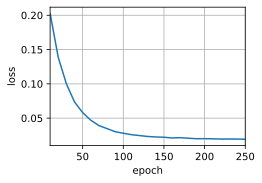

In [26]:
embed_size, num_hiddens, num_layers, dropout = 32, 32, 2, 0.1
batch_size, num_steps = 64, 10
lr, num_epochs, device = 0.005, 250, d2l.try_gpu()

train_iter, src_vocab, tgt_vocab = d2l.load_data_nmt(batch_size, num_steps)

encoder = d2l.Seq2SeqEncoder(
    len(src_vocab), embed_size, num_hiddens, num_layers, dropout  # type: ignore
)

decoder = Seq2SeqAttentionDecoder(
    len(tgt_vocab), embed_size, num_hiddens, num_layers, dropout
)

net = d2l.EncoderDecoder(encoder, decoder)

train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)

In [ ]:
engs = ["go .", "i lost .", "he's calm .", "i'm home ."]

fras = ["va !", "j'ai perdu .", "il est calme .", "je suis chez moi ."]

for eng, fra in zip(engs, fras):
    translation, dec_attention_weight_seq = d2l.predict_seq2seq(
        net, eng, src_vocab, tgt_vocab, num_steps, device, True
    )

    print(f"{eng} => {translation}, ", f"bleu {d2l.bleu(translation, fra, k=2):.3f}")

go . => va !,  bleu 1.000
i lost . => j'ai perdu .,  bleu 1.000
he's calm . => il est malade .,  bleu 0.658
i'm home . => je suis chez moi .,  bleu 1.000


In [31]:
attention_weights = torch.cat(
    [step[0][0][0] for step in dec_attention_weight_seq], 0
).reshape((1, 1, -1, num_steps))

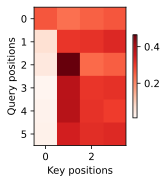

In [ ]:
d2l.show_heatmaps(
    attention_weights[:, :, :, : len(engs[-1].split()) + 1].cpu(),
    xlabel="Key positions",
    ylabel="Query positions",
)